# EDA combined fragrance data
**Project:** Fragheadsunited AI Fragrance Recommendation Engine
**Dataset:** `combined_fragrance_data.xlsx`
**Expected columns (13):** `url`, `rating`, `notes`, `designer`, `reviews`, `description`, `title`, `gender_raw`, `style`, `notes_text`, `reviews_text`, `gender`, `embedding_text`

This notebook is a detailed Exploratory Data Analysis (EDA) of the combined fragrance dataset. It runs top to bottom. After each section there is a short Markdown cell with findings in simple English.

> **Heads up:** the raw file has many more columns than the expected 13, and some columns are polluted by shifted rows (multi-line review text that leaked into the wrong columns during the original CSV parsing). This EDA makes those problems visible.


## 1. Setup & Imports

Install and import the libraries. The pip install cell only needs to run once per environment.

In [1]:
# Install required libraries (run once)
%pip install -q pandas numpy matplotlib seaborn openpyxl nltk spacy textblob wordcloud scikit-learn langdetect

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data & plotting
import os
import re
import ast
import warnings
from itertools import combinations
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from langdetect import detect, DetectorFactory

# ML helpers
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")
DetectorFactory.seed = 42          # make language detection deterministic

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14

print("Imports loaded.")

Imports loaded.


In [3]:
# Download NLTK stopwords
for pkg in ["stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"Could not download {pkg}: {e}")

STOPWORDS_EN = set(stopwords.words("english"))
print("NLP ready. Stopwords:", len(STOPWORDS_EN))

NLP ready. Stopwords: 198


## 2. Load data

We load the Excel file. Note: the file is large (~140 MB), so loading can take a minute or more.

In [4]:
# Find the file (robust against small name differences)
CANDIDATES = [
    "combined_fragrance_data.xlsx",
    "combined_fragrance_data 1.csv.xlsx",
    "combined_fragrance_data 1.xlsx",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    matches = [f for f in os.listdir(".") if "combined" in f.lower() and f.lower().endswith(".xlsx")]
    DATA_PATH = matches[0] if matches else "combined_fragrance_data.xlsx"

print("Loading:", DATA_PATH, "(this can take a while)")
df_raw = pd.read_excel(DATA_PATH, engine="openpyxl")
print("Done loading.")

Loading: combined_fragrance_data.xlsx (this can take a while)


Done loading.


In [5]:
# How many columns does the file REALLY have?
print("Raw shape (rows, cols):", df_raw.shape)

EXPECTED = ["url", "rating", "notes", "designer", "reviews", "description", "title",
            "gender_raw", "style", "notes_text", "reviews_text", "gender", "embedding_text"]
present = [c for c in EXPECTED if c in df_raw.columns]
extra = [c for c in df_raw.columns if c not in EXPECTED]

print(f"\nExpected columns present : {len(present)} / {len(EXPECTED)}")
print(f"Unexpected extra columns : {len(extra)}")
if extra:
    print(">> These come from multi-line text fields that leaked into wrong columns during CSV parsing.")

# Keep only the 13 expected columns
df = df_raw[present].copy()
del df_raw  # free memory
print("\nWorking dataframe shape:", df.shape)

Raw shape (rows, cols): (37518, 1944)

Expected columns present : 13 / 13
Unexpected extra columns : 1931
>> These come from multi-line text fields that leaked into wrong columns during CSV parsing.



Working dataframe shape: (37518, 13)


In [6]:
# First rows
df.head()

,url,rating,notes,designer,reviews,description,title,gender_raw,style,notes_text,reviews_text,gender,embedding_text
0,https://www.fragrantica.com/perfume/Franck-Oli...,2.33,"['Mandarin Orange', 'Freesia', 'Orange Blossom...",franck olivier perfumes and colognes,['Smells like a multisex version of Intimately...,Baby Boy by Franck Olivier is a Citrus fragran...,Baby Boy Franck Olivier for men,NaN,NaN,"Mandarin Orange, Freesia, Orange Blossom, Pear...",Smells like a multisex version of Intimately Y...,men,Baby Boy Franck Olivier for men. Brand: franck...
1,https://www.fragrantica.com/perfume/Guerlain/N...,3.81,"['Neroli', 'Vetiver', 'Basil', 'Fig']",guerlain perfumes and colognes,"[""the opening is too sharp that it reminds me ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"adjective I would use is """"balm-like"""". It sm...",rather more like plant sap or dew. It\'s not ...,but the neroli and vetiver blend to create th...,serene scent which reminds me of smooth pebbl...,it\'s unisex,it\'s natural-smelling and it has surprising ...,but I think these notes just contribute to th...,with the neroli filling in the space with its...,cloud-like uplift. \nThis is not miles away f...,like most AAs,is not considerable but you will get strong p...,and I\'m glad to see Guerlain slow down a lit...,"""""Beautiful aroma! Well this deserves much hi..."
3,https://www.fragrantica.com/perfume/Jean-Paul-...,4,"['Orange Blossom', 'Star Anise', 'Pear', 'Rose...",jean paul gaultier perfumes and colognes,['I must ask. What part of the country did thi...,Classique Love Actually by Jean Paul Gaultier ...,Classique Love Actually Jean Paul Gaultier for...,NaN,NaN,"Orange Blossom, Star Anise, Pear, Rose, Mandar...",I must ask. What part of the country did this ...,women,Classique Love Actually Jean Paul Gaultier for...
4,https://www.fragrantica.com/perfume/Santa-Mari...,4.22,"['Petitgrain', 'Orange', 'Bergamot', 'Lemon Ve...",santa maria novella perfumes and colognes,['Beautiful and uplifting. Initially fresh and...,Zagara (Orange Blossom) by Santa Maria Novella...,Zagara (Orange Blossom) Santa Maria Novella fo...,NaN,NaN,"Petitgrain, Orange, Bergamot, Lemon Verbena, L...",Why do the pretty ones always break your heart...,women,Zagara (Orange Blossom) Santa Maria Novella fo...


In [7]:
# Shape and columns
print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:", list(df.columns))

Rows   : 37518
Columns: 13

Columns: ['url', 'rating', 'notes', 'designer', 'reviews', 'description', 'title', 'gender_raw', 'style', 'notes_text', 'reviews_text', 'gender', 'embedding_text']


In [8]:
# Dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37518 entries, 0 to 37517
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             37499 non-null  object
 1   rating          11777 non-null  object
 2   notes           37513 non-null  str   
 3   designer        37494 non-null  str   
 4   reviews         37486 non-null  str   
 5   description     35217 non-null  str   
 6   title           35221 non-null  str   
 7   gender_raw      2268 non-null   object
 8   style           2266 non-null   str   
 9   notes_text      35204 non-null  str   
 10  reviews_text    32019 non-null  str   
 11  gender          35190 non-null  str   
 12  embedding_text  35184 non-null  str   
dtypes: object(3), str(10)
memory usage: 3.7+ MB


In [9]:
# Summary of all columns (including text)
df.describe(include="all").T

,count,unique,top,freq
url,37499,37485,e,5
rating,11777.0,2465.0,3.75,551.0
notes,37513,36619,['Agarwood (Oud)'],66
designer,37494,6336,victoria's secret perfumes and colognes,507
reviews,37486,34699,"[""So today it's this fragrance's turn. The bot...",18
description,35217,35149,clean,7
title,35221,35198,fresh,4
gender_raw,2268,2233,unisex,9
style,2266,2224,sweet,9
notes_text,35204,34327,Agarwood (Oud),65


In [10]:
# Duplicates
print("Fully identical rows:", df.duplicated().sum())
if "url" in df.columns:
    print("Duplicate url's (same perfume):", df["url"].duplicated().sum())
if "title" in df.columns:
    print("Duplicate titles:", df["title"].duplicated().sum())

Fully identical rows: 0
Duplicate url's (same perfume): 32
Duplicate titles: 2319


In [11]:
# Missing values per column
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing", ascending=False)
missing

,missing,pct
style,35252,93.96
gender_raw,35250,93.95
rating,25741,68.61
reviews_text,5499,14.66
embedding_text,2334,6.22
gender,2328,6.21
notes_text,2314,6.17
description,2301,6.13
title,2297,6.12
reviews,32,0.09


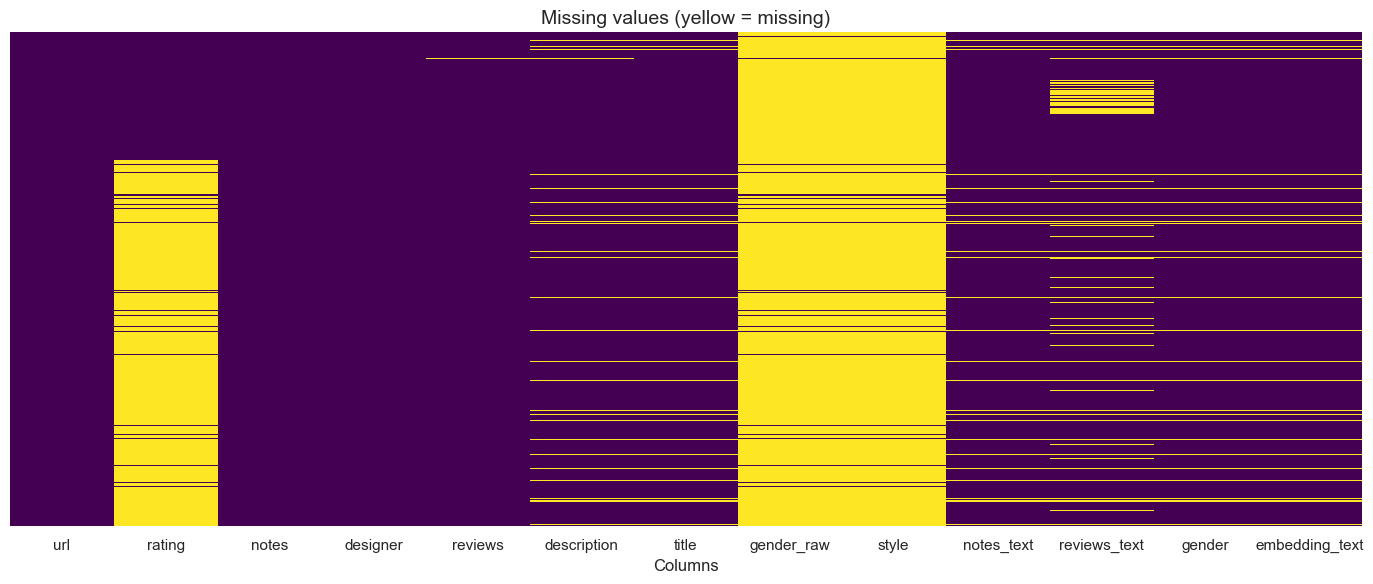

In [12]:
# Missing values heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values (yellow = missing)")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

### Findings Load & first look

- **File structure:** The raw file has far more columns than the expected 13. The extra columns are leaked multi-line review text from the original CSV parsing. We keep only the 13 known columns.
- **Size:** After selecting the 13 columns we have about **37,000 perfumes**.
- **Dtypes:** `rating` loads as `object` (not pure numeric) `reviews` turns out to be alist of review texts, not a count.
- **Duplicates:** A few dozen duplicate `url`'s — these should be removed before use.
- **Missing values:** `reviews_text`, `rating` and especially `style` have many gaps (see heatmap).

## 3. Text columns

We analyse `title`, `description`, `notes_text`, `reviews_text` and `embedding_text`: text lengths, most common two-word phrases (bigrams), language, and the perfume notes.

In [13]:
# Which text columns are present?
TEXT_COLS = [c for c in ["title", "description", "notes_text", "reviews_text", "embedding_text"] if c in df.columns]
print("Text columns:", TEXT_COLS)

# Treat as string (NaN -> empty string for length math)
for col in TEXT_COLS:
    df[col + "_str"] = df[col].fillna("").astype(str)

Text columns: ['title', 'description', 'notes_text', 'reviews_text', 'embedding_text']


In [14]:
# Text length and word count per column
length_stats = {}
for col in TEXT_COLS:
    s = df[col + "_str"]
    char_len = s.str.len()
    word_len = s.str.split().apply(len)
    df[col + "_wordcount"] = word_len
    length_stats[col] = {
        "mean_chars": round(char_len.mean(), 1),
        "median_chars": int(char_len.median()),
        "max_chars": int(char_len.max()),
        "mean_words": round(word_len.mean(), 1),
        "median_words": int(word_len.median()),
        "empty": int((s.str.strip() == "").sum()),
    }
pd.DataFrame(length_stats).T

,mean_chars,median_chars,max_chars,mean_words,median_words,empty
title,43.1,40.0,1538.0,7.6,7.0,2297.0
description,188.3,168.0,2883.0,31.5,28.0,2301.0
notes_text,80.7,76.0,6848.0,10.4,10.0,2314.0
reviews_text,954.9,1500.0,4262.0,170.0,244.0,5499.0
embedding_text,1320.8,1758.0,4950.0,225.6,298.0,2334.0


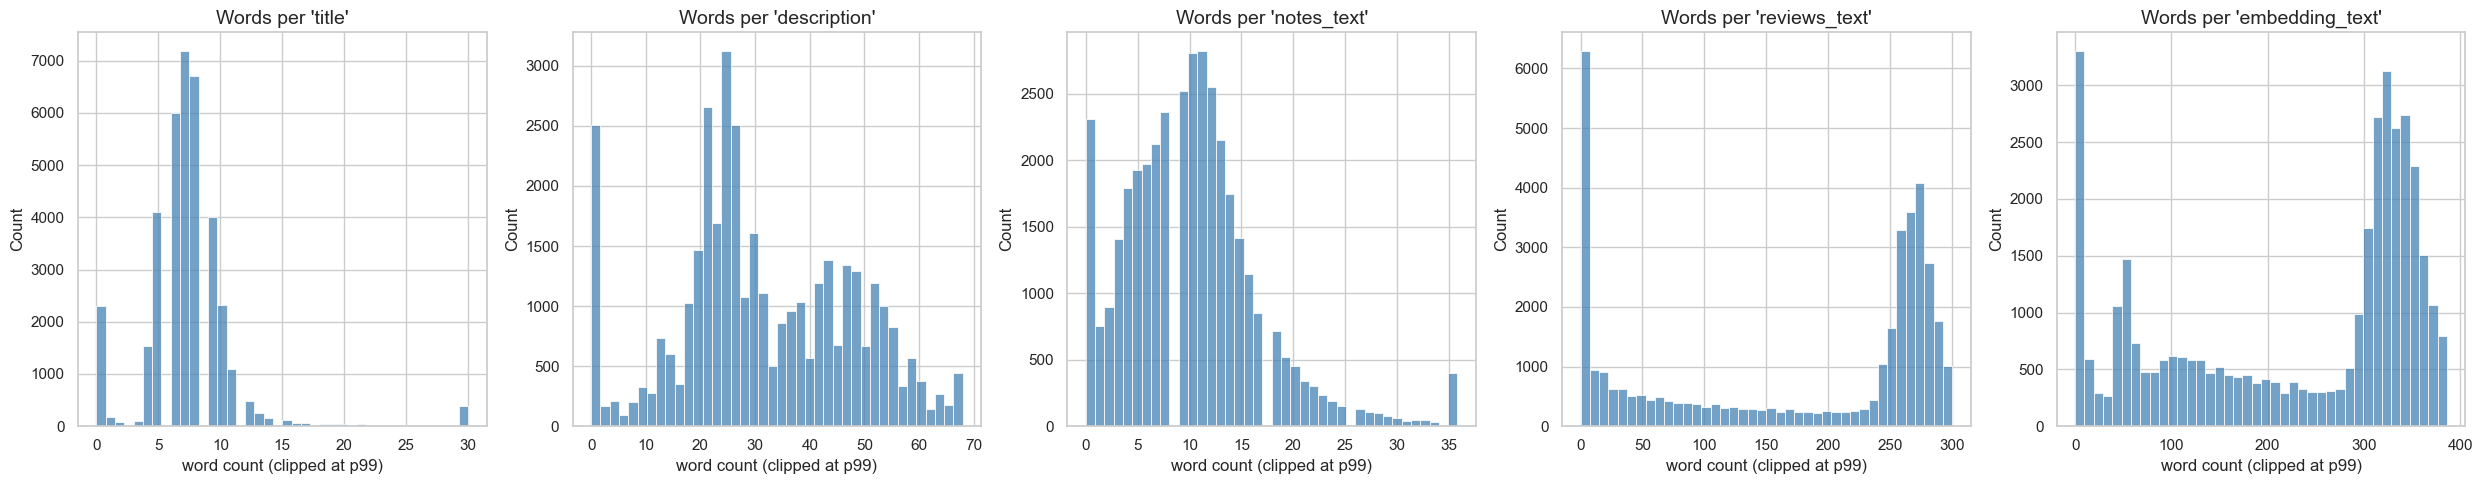

In [15]:
# Word count distribution per text column
fig, axes = plt.subplots(1, len(TEXT_COLS), figsize=(5 * len(TEXT_COLS), 5))
if len(TEXT_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, TEXT_COLS):
    data = df[col + "_wordcount"]
    upper = max(data.quantile(0.99), 1)   # clip at p99 so outliers don't flatten the plot
    sns.histplot(data.clip(upper=upper), bins=40, ax=ax, color="steelblue")
    ax.set_title(f"Words per '{col}'")
    ax.set_xlabel("word count (clipped at p99)")
plt.tight_layout()
plt.show()

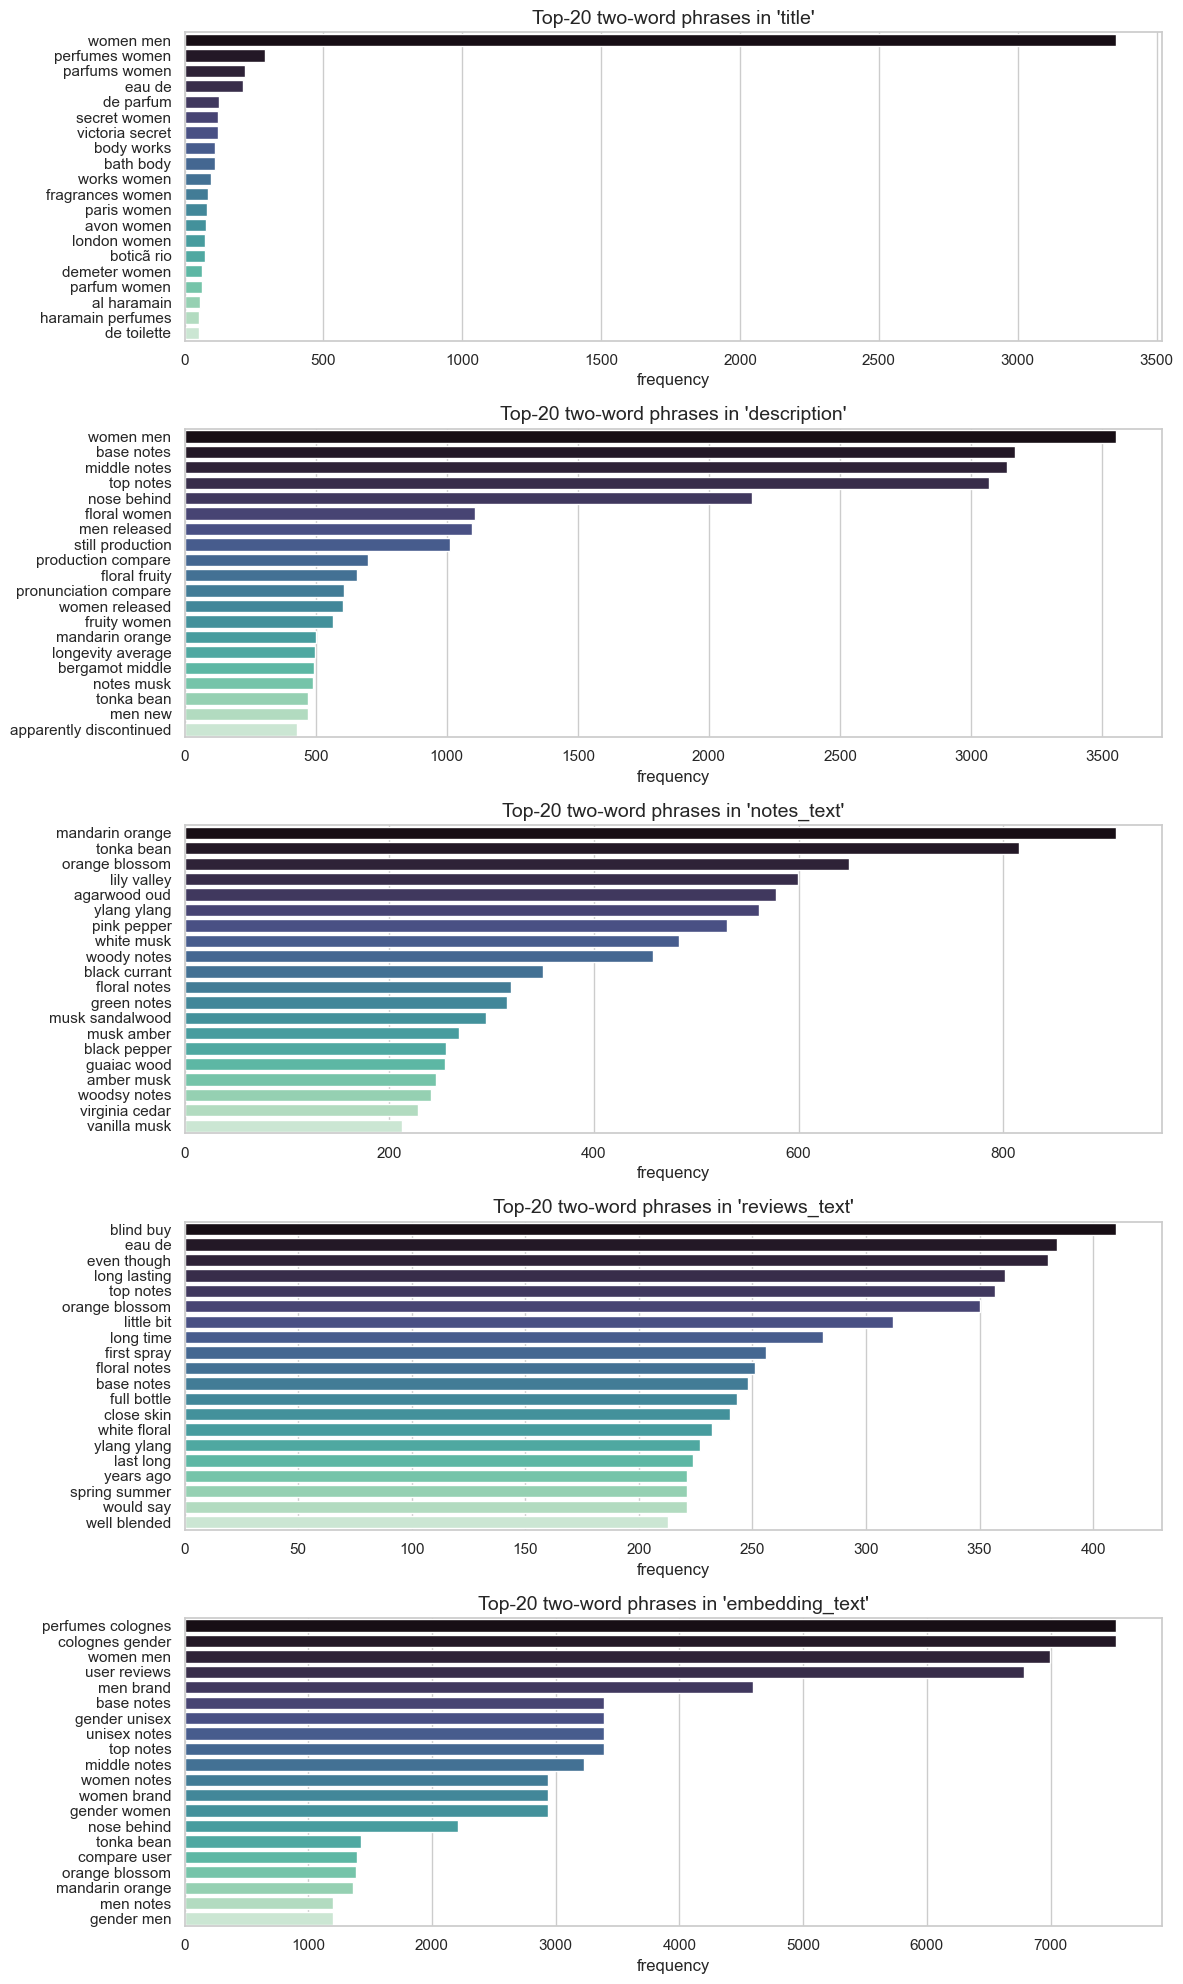

In [16]:
# Top-20 BIGRAMS (two-word phrases) per text column.
# Bigrams like "white musk" or "tonka bean" are more meaningful than single words for fragrance text.
EXTRA_STOP = ["perfume", "fragrance", "scent", "smell", "smells", "like", "really", "just"]
BIGRAM_STOP = list(STOPWORDS_EN | set(EXTRA_STOP))

def top_bigrams(series, n=20):
    texts = series.fillna("").astype(str)
    texts = texts[texts.str.strip() != ""]
    if len(texts) == 0:
        return []
    if len(texts) > 8000:                     # sample for speed on big columns
        texts = texts.sample(8000, random_state=42)
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=BIGRAM_STOP, min_df=3)
    try:
        X = vec.fit_transform(texts)
    except ValueError:
        return []
    sums = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    order = sums.argsort()[::-1][:n]
    return [(vocab[i], int(sums[i])) for i in order]

fig, axes = plt.subplots(len(TEXT_COLS), 1, figsize=(12, 4 * len(TEXT_COLS)))
if len(TEXT_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, TEXT_COLS):
    pairs = top_bigrams(df[col], n=20)
    if pairs:
        words, counts = zip(*pairs)
        sns.barplot(x=list(counts), y=list(words), ax=ax, palette="mako")
    ax.set_title(f"Top-20 two-word phrases in '{col}'")
    ax.set_xlabel("frequency")
plt.tight_layout()
plt.show()

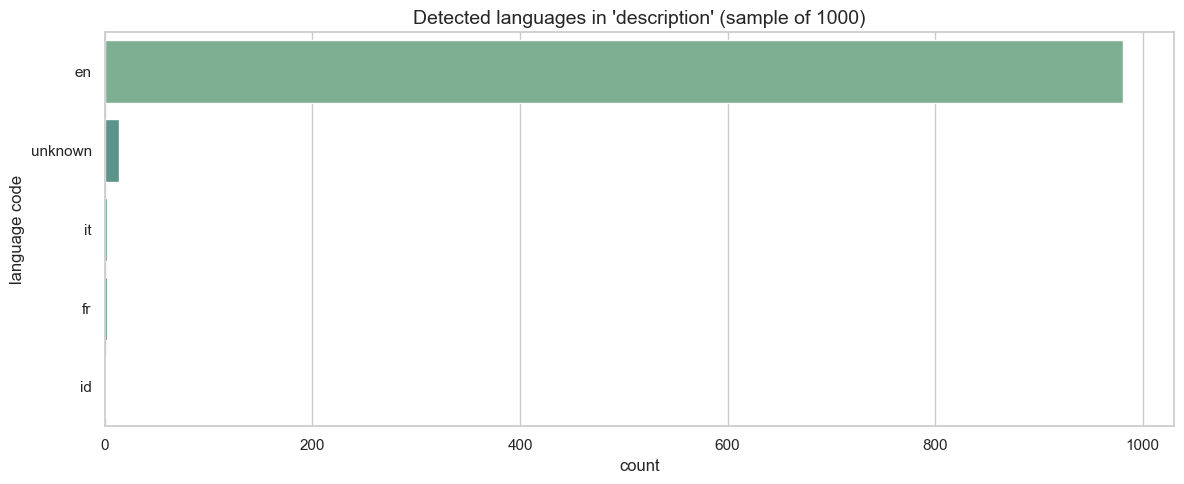

description_str
en         0.981
unknown    0.014
it         0.002
fr         0.002
id         0.001
Name: proportion, dtype: float64


In [17]:
# Language detection on a sample (langdetect is slow, so we sample)
def detect_lang_safe(text):
    text = str(text).strip()
    if len(text) < 20:
        return "unknown"
    try:
        return detect(text)
    except Exception:
        return "unknown"

lang_col = "description" if "description" in df.columns else TEXT_COLS[0]
non_empty = df[lang_col + "_str"].replace("", np.nan).dropna()
sample = non_empty.sample(min(1000, len(non_empty)), random_state=42)
langs = sample.apply(detect_lang_safe)

plt.figure(figsize=(12, 5))
sns.countplot(y=langs, order=langs.value_counts().index, palette="crest")
plt.title(f"Detected languages in '{lang_col}' (sample of {len(sample)})")
plt.xlabel("count")
plt.ylabel("language code")
plt.tight_layout()
plt.show()
print(langs.value_counts(normalize=True).round(3).head(10))

In [18]:
# Helper: parse a notes field into a list (handles list-string and comma text)
def parse_list_field(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s:
        return []
    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple)):
                return [str(x).strip() for x in parsed if str(x).strip()]
        except Exception:
            pass
    return [p.strip() for p in s.split(",") if p.strip()]

# Count notes
note_source_col = "notes_text" if "notes_text" in df.columns else "notes"
df["notes_list"] = df[note_source_col].apply(lambda v: [n.title() for n in parse_list_field(v)])
df["n_notes"] = df["notes_list"].apply(len)

note_counter = Counter()
for lst in df["notes_list"]:
    note_counter.update(lst)

print(f"Unique notes in '{note_source_col}':", len(note_counter))
top_notes = note_counter.most_common(20)
top_notes

Unique notes in 'notes_text': 4222


[('Musk', 12316),
 ('Sandalwood', 9063),
 ('Bergamot', 8981),
 ('Amber', 8830),
 ('Jasmine', 8636),
 ('Patchouli', 8200),
 ('Vanilla', 7929),
 ('Rose', 7123),
 ('Cedar', 6145),
 ('Vetiver', 4453),
 ('Mandarin Orange', 3784),
 ('Tonka Bean', 3646),
 ('Lemon', 3415),
 ('Lavender', 3249),
 ('Orange Blossom', 2810),
 ('Leather', 2647),
 ('Lily-Of-The-Valley', 2612),
 ('Cardamom', 2581),
 ('Violet', 2530),
 ('Grapefruit', 2479)]

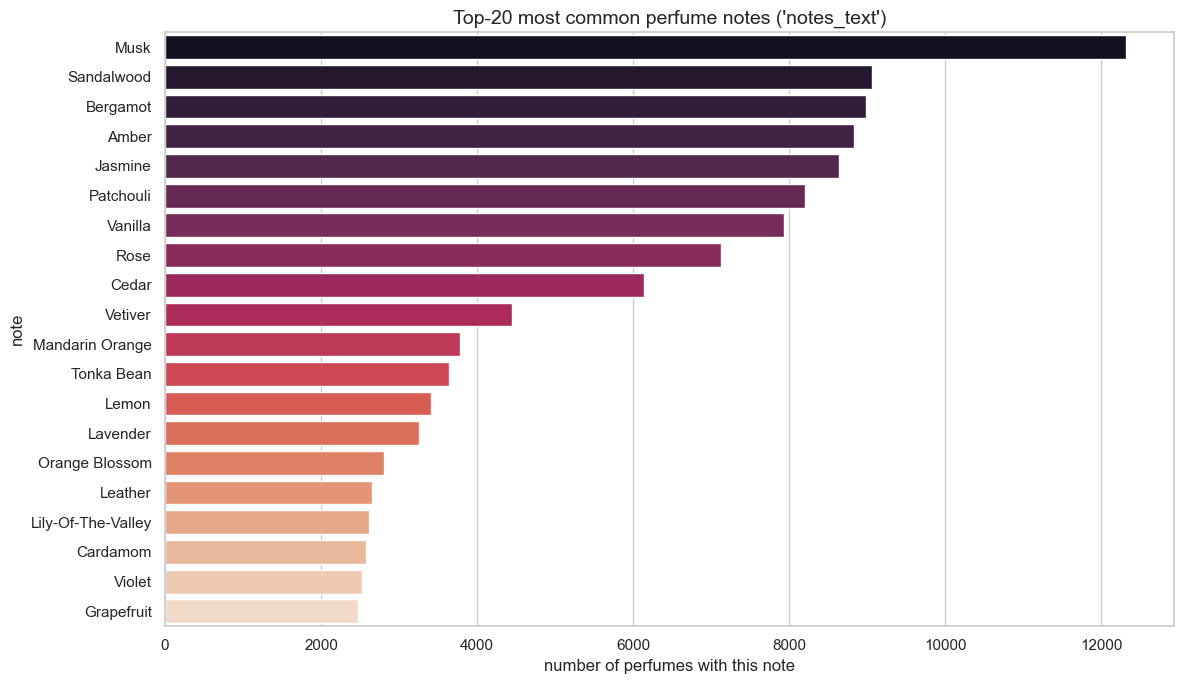

In [19]:
# Top-20 most common perfume notes
if top_notes:
    notes, counts = zip(*top_notes)
    plt.figure(figsize=(12, 7))
    sns.barplot(x=list(counts), y=list(notes), palette="rocket")
    plt.title(f"Top-20 most common perfume notes ('{note_source_col}')")
    plt.xlabel("number of perfumes with this note")
    plt.ylabel("note")
    plt.tight_layout()
    plt.show()

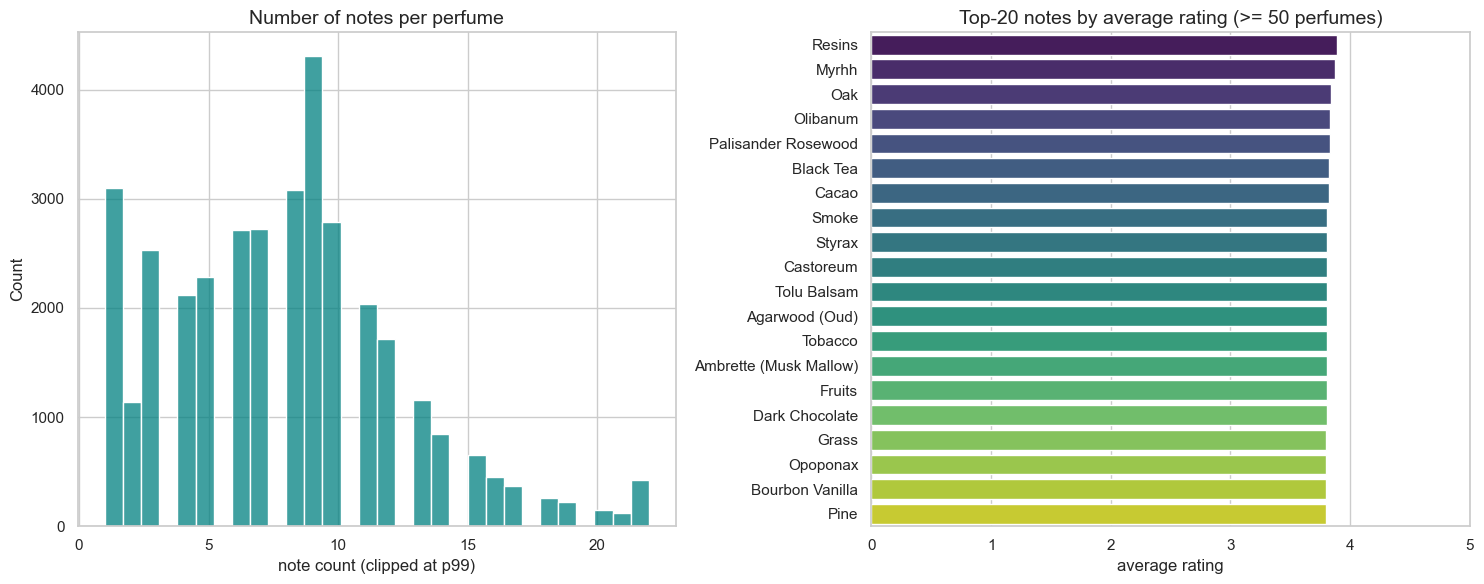

In [20]:
# How many notes does a perfume have? + which notes have the highest average rating
df["rating_num"] = pd.to_numeric(df["rating"], errors="coerce")
df.loc[~df["rating_num"].between(0, 5), "rating_num"] = np.nan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: number of notes per perfume
notes_nonzero = df.loc[df["n_notes"] > 0, "n_notes"]
sns.histplot(notes_nonzero.clip(upper=notes_nonzero.quantile(0.99)), bins=30, ax=ax1, color="teal")
ax1.set_title("Number of notes per perfume")
ax1.set_xlabel("note count (clipped at p99)")

# Right: top notes by average rating (only notes used by enough perfumes)
note_sum, note_cnt = Counter(), Counter()
for lst, r in zip(df["notes_list"], df["rating_num"]):
    if pd.notna(r):
        for nt in set(lst):
            note_sum[nt] += r
            note_cnt[nt] += 1
MIN_PERFUMES = 50
note_avg = {nt: note_sum[nt] / note_cnt[nt] for nt in note_cnt if note_cnt[nt] >= MIN_PERFUMES}
top_rated = sorted(note_avg.items(), key=lambda x: -x[1])[:20]
if top_rated:
    nts, avgs = zip(*top_rated)
    sns.barplot(x=list(avgs), y=list(nts), ax=ax2, palette="viridis")
    ax2.set_xlim(0, 5)
ax2.set_title(f"Top-20 notes by average rating (>= {MIN_PERFUMES} perfumes)")
ax2.set_xlabel("average rating")
plt.tight_layout()
plt.show()

### Findings text columns

- **Lengths:** `reviews_text` and `embedding_text` are by far the longest columns (they hold joined review text); `title` and `notes_text` are short. `reviews_text` is empty for about 15% of perfumes.
- **Two-word phrases:** Prose columns show meaningful pairs (e.g. *white musk*, *tonka bean*, *long lasting*), which carry more signal than single words.
- **Language:** Mostly English, with a small tail of other languages (international perfume names). Relevant for the embedding model.
- **Notes:** ~4,000 unique notes; classics dominate (Musk, Vanilla, Sandalwood, Bergamot, Rose). Most perfumes list a handful to a dozen notes. Note names need normalising (variants, duplicates).

## 4. Categorical columns

We look at `designer`, `gender`, `gender_raw` and `style`: value counts, bar charts and the top-20 designers.

In [21]:
# Cardinality (unique values) per categorical column
CAT_COLS = [c for c in ["designer", "gender", "gender_raw", "style"] if c in df.columns]
for col in CAT_COLS:
    print(f"{col:12s}: {df[col].nunique()} unique values, {df[col].isna().sum()} missing")

designer    : 6336 unique values, 24 missing
gender      : 2188 unique values, 2328 missing
gender_raw  : 2233 unique values, 35250 missing
style       : 2224 unique values, 35252 missing


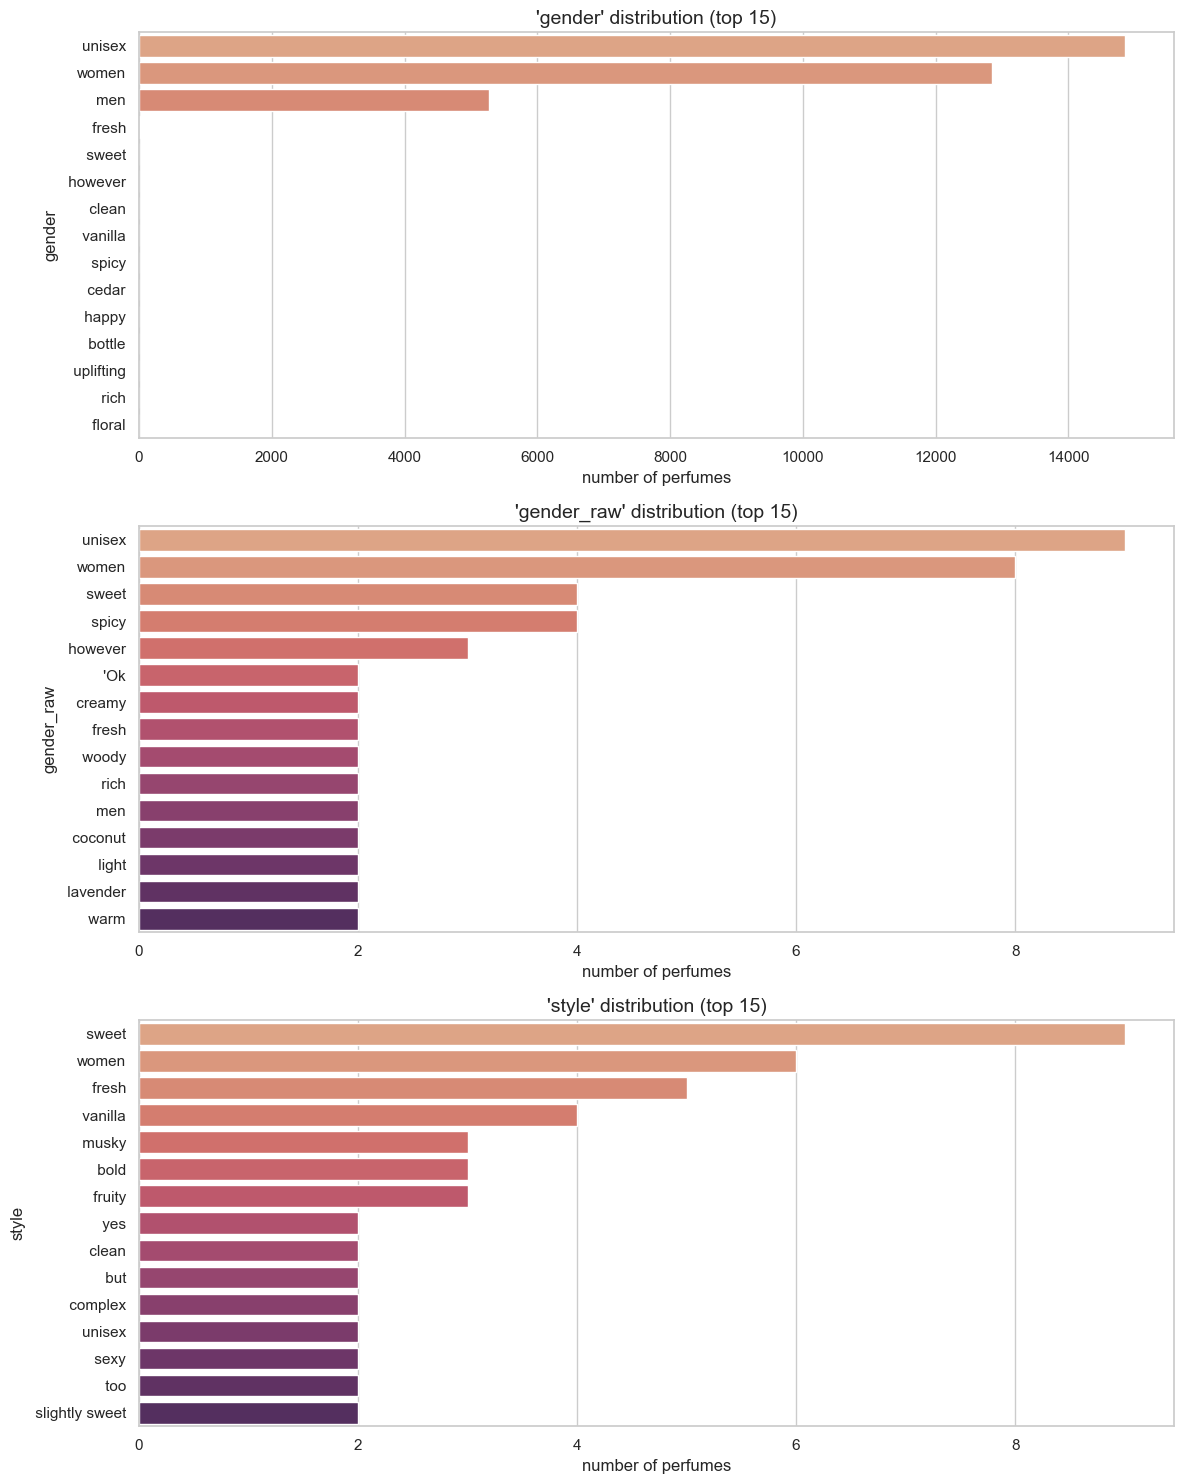


=== gender ===
gender
unisex      14847
women       12845
men          5270
NaN          2328
 fresh          7
 sweet          5
 however        5
 clean          4
 vanilla        3
 spicy          3
Name: count, dtype: int64

=== gender_raw ===
gender_raw
NaN         35250
unisex          9
women           8
 sweet          4
 spicy          4
 however        3
 'Ok            2
 creamy         2
 fresh          2
 woody          2
Name: count, dtype: int64

=== style ===
style
NaN         35252
 sweet          9
women           6
 fresh          5
 vanilla        4
 musky          3
 bold           3
 fruity         3
 yes            2
 clean          2
Name: count, dtype: int64


In [22]:
# Value counts + bar chart for gender, gender_raw and style (top 15)
low_card = [c for c in ["gender", "gender_raw", "style"] if c in df.columns]
fig, axes = plt.subplots(len(low_card), 1, figsize=(12, 5 * len(low_card)))
if len(low_card) == 1:
    axes = [axes]
for ax, col in zip(axes, low_card):
    vc = df[col].value_counts().head(15)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, palette="flare")
    ax.set_title(f"'{col}' distribution (top 15)")
    ax.set_xlabel("number of perfumes")
plt.tight_layout()
plt.show()

for col in low_card:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False).head(10))

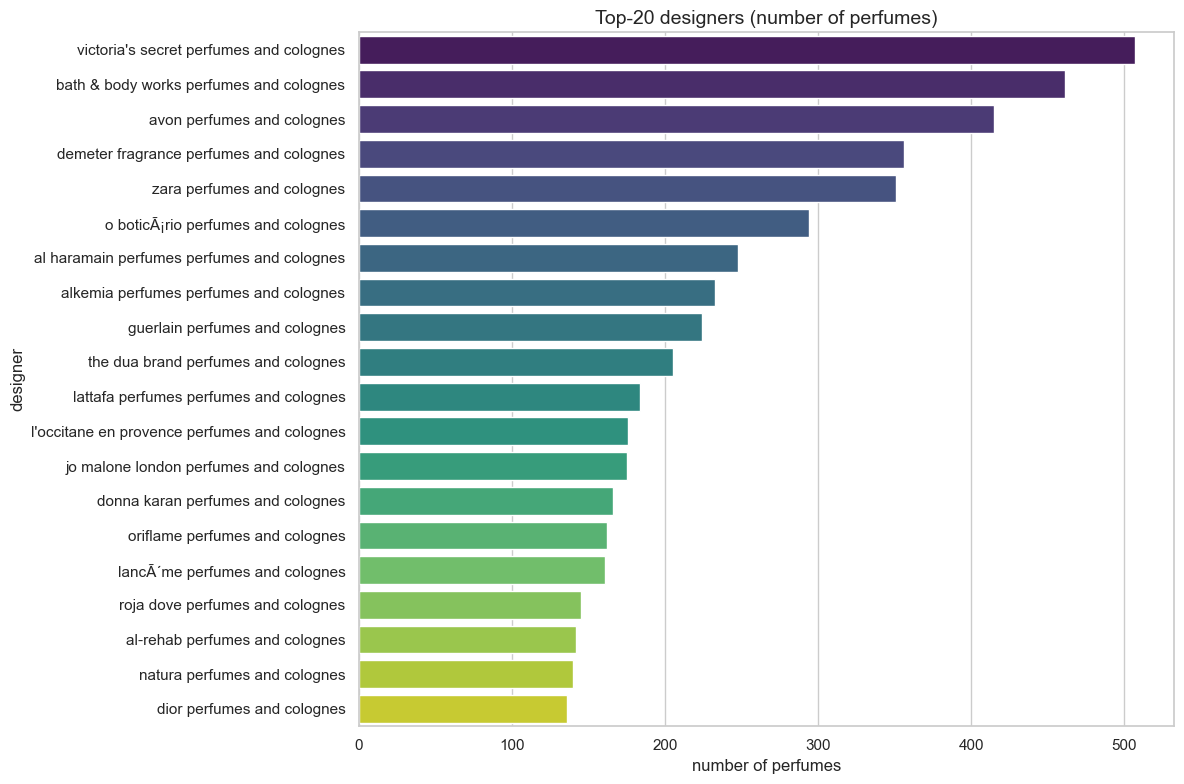

In [23]:
# Top-20 designers
if "designer" in df.columns:
    top_designers = df["designer"].value_counts().head(20)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_designers.values, y=top_designers.index, palette="viridis")
    plt.title("Top-20 designers (number of perfumes)")
    plt.xlabel("number of perfumes")
    plt.ylabel("designer")
    plt.tight_layout()
    plt.show()

### Findings categorical columns

- **Gender:** Most perfumes fall cleanly into **unisex / women / men** (~33k together). A small group is polluted by leaked words (e.g. *fresh*, *sweet*) from shifted rows, plus ~2,300 missing. The three main classes are usable.
- **gender_raw vs gender:** `gender_raw` is the raw scrape text ("for women and men"); `gender` is the cleaned version. The mapping looks mostly consistent.
- **Style:** Mostly empty (>90%) and the non-empty values are partly review-text fragments.`style` is basically unusable as-is.
- **Designer:** Long tail a few big houses, many niche brands with few perfumes.

## 5. Numeric columns

`rating` and `reviews`.
- `rating` loads as text and contains both valid scores and leaked text fragments we force it to numeric and keep only values in `[0, 5]`.
- `reviews` is not a count but a list of review texts. So we derive a real numeric measure: `n_reviews` = number of reviews per perfume.

In [24]:
# rating is already cleaned into rating_num in section 3; report the pollution
n_valid = df["rating_num"].notna().sum()
print(f"rating: {n_valid} valid numeric values out of {len(df)} "
      f"({n_valid/len(df)*100:.1f}%) -> {df['rating_num'].isna().sum()} empty/polluted")

# derive n_reviews from the reviews list
df["n_reviews"] = df["reviews"].apply(lambda v: len(parse_list_field(v)))

NUM_COLS = ["rating_num", "n_reviews"]
df[NUM_COLS].describe()

rating: 9501 valid numeric values out of 37518 (25.3%) -> 28017 empty/polluted


,rating_num,n_reviews
count,9501.000000,37518.000000
mean,3.737758,29.231889
std,0.409531,82.693885
min,0.500000,0.000000
25%,3.500000,1.000000
50%,3.750000,4.000000
75%,4.000000,13.000000
max,5.000000,540.000000


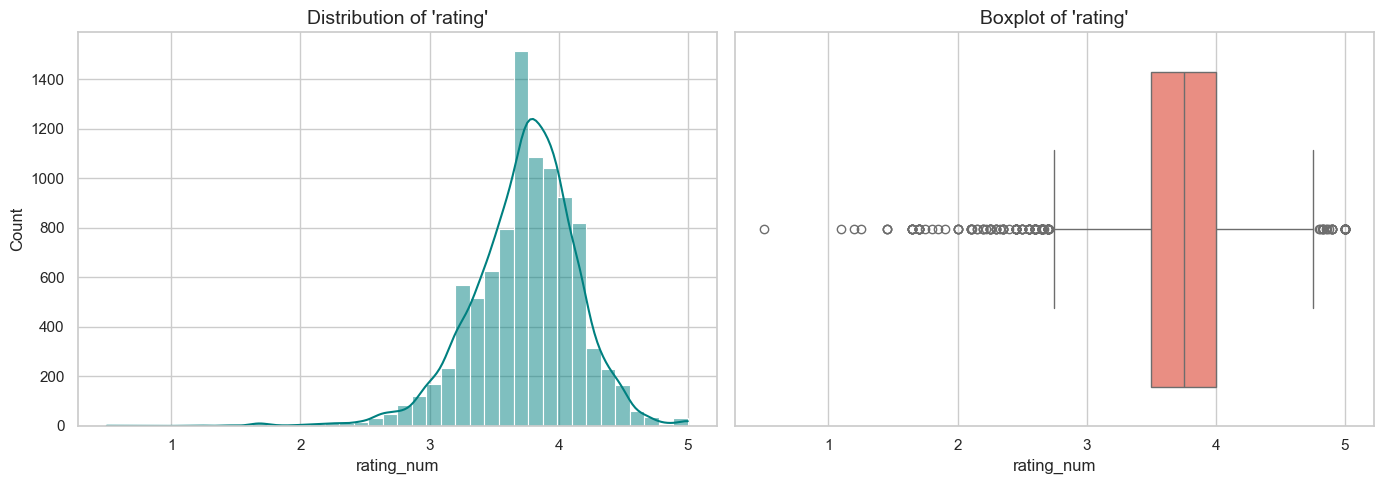

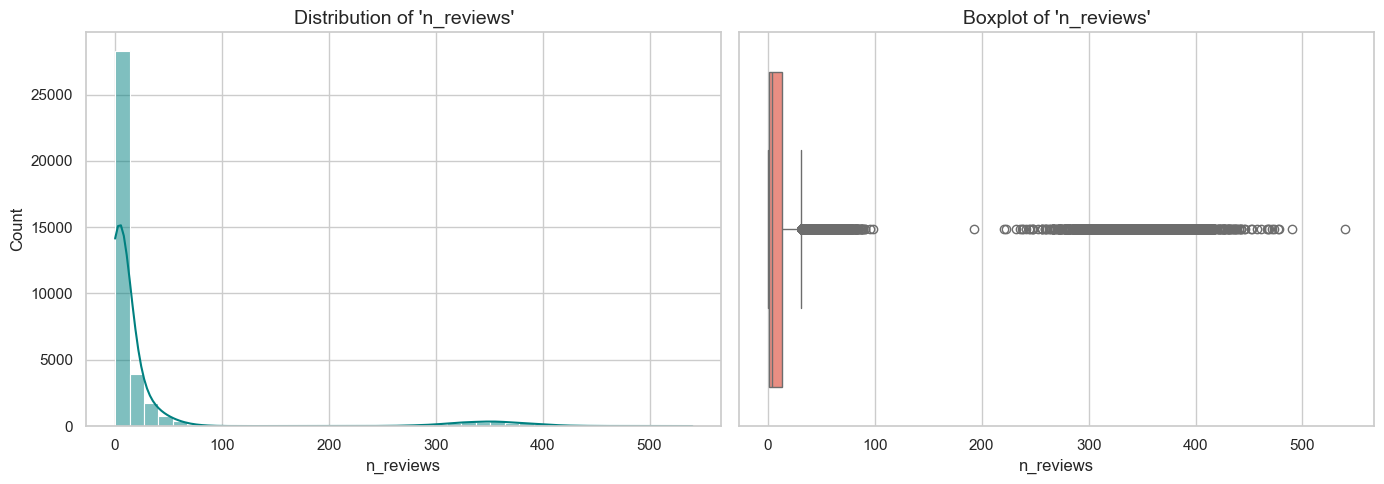

In [25]:
# Histogram + boxplot per numeric column
for col, label in [("rating_num", "rating"), ("n_reviews", "n_reviews")]:
    s = df[col].dropna()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(s, kde=True, bins=40, ax=ax1, color="teal")
    ax1.set_title(f"Distribution of '{label}'")
    sns.boxplot(x=s, ax=ax2, color="salmon")
    ax2.set_title(f"Boxplot of '{label}'")
    plt.tight_layout()
    plt.show()

In [26]:
# Outlier detection with the IQR method (safe against empty columns)
for col in NUM_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        print(f"{col:10s}: no valid values -> skip")
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < low) | (s > high)]
    print(f"{col:10s}: IQR bounds [{low:.2f}, {high:.2f}] -> {len(outliers)} outliers "
          f"({len(outliers)/len(s)*100:.2f}%)")

# Correlation between the two numeric columns (single number is enough for 2 variables)
corr_val = df[["rating_num", "n_reviews"]].corr().iloc[0, 1]
print(f"\nCorrelation rating vs n_reviews: {corr_val:.3f}")

rating_num: IQR bounds [2.75, 4.75] -> 199 outliers (2.09%)
n_reviews : IQR bounds [-17.00, 31.00] -> 4533 outliers (12.08%)

Correlation rating vs n_reviews: 0.107


### Findings Numeric columns

- **rating:** Only ~25% of rows have a valid numeric rating; the rest is empty or polluted by shifted rows. Valid ratings sit in `[0.5, 5.0]` with a peak around 3.5–4.0.
- **reviews / n_reviews:** `reviews` is review text, not a count. The derived `n_reviews` is strongly right-skewed: most perfumes have few reviews, a few have many (outliers).
- **Correlation:** Weak positive link between `n_reviews` and `rating` more reviews goes slightly together with a higher/steadier score, but the effect is small.

## 6. Combination analyses

Average rating per designer and per gender, reviews vs rating, notes per gender, a note co-occurrence heatmap, and review sentiment.

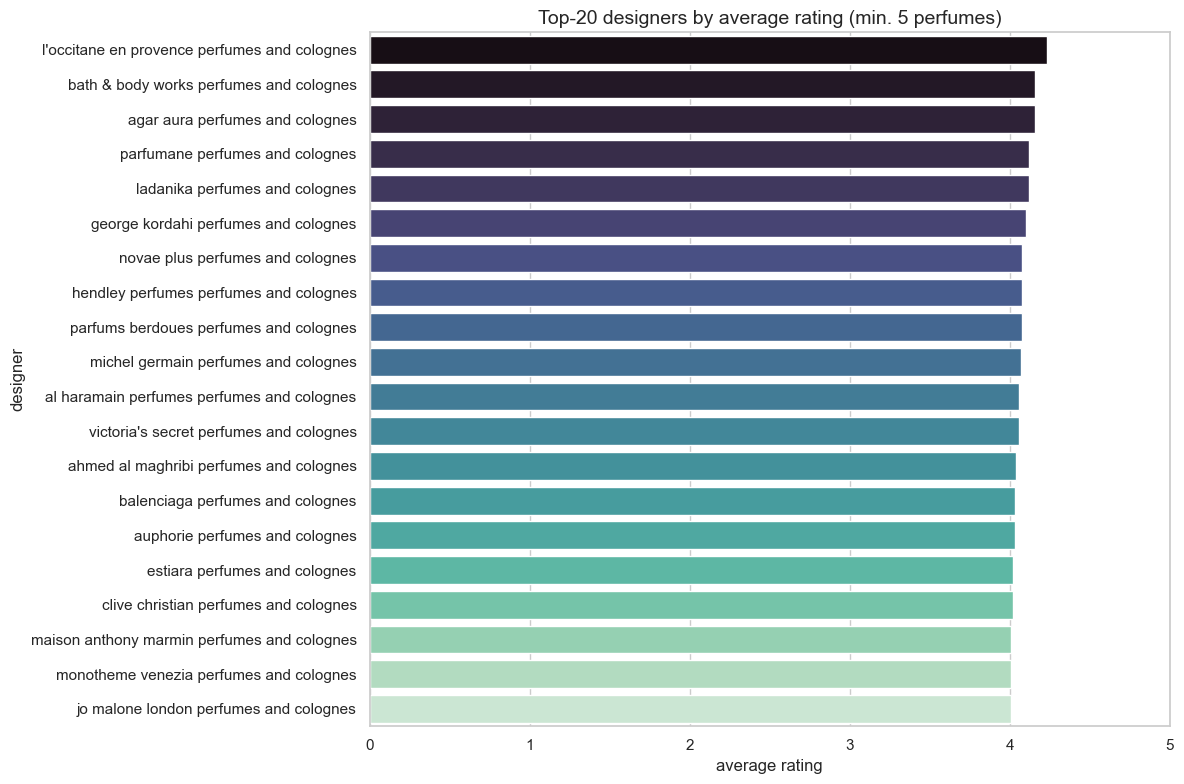

,mean,count
designer,,
l'occitane en provence perfumes and colognes,4.232000,5
bath & body works perfumes and colognes,4.159048,21
agar aura perfumes and colognes,4.158333,6
parfumane perfumes and colognes,4.121429,7
ladanika perfumes and colognes,4.117143,7
george kordahi perfumes and colognes,4.100000,5
novae plus perfumes and colognes,4.078571,7
hendley perfumes perfumes and colognes,4.075000,6
parfums berdoues perfumes and colognes,4.073333,6


In [27]:
# Average rating per designer (min. 5 perfumes with a valid rating)
if {"designer"}.issubset(df.columns):
    grp = df.dropna(subset=["rating_num"]).groupby("designer")["rating_num"].agg(["mean", "count"])
    grp = grp[grp["count"] >= 5].sort_values("mean", ascending=False).head(20)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=grp["mean"], y=grp.index, palette="mako")
    plt.title("Top-20 designers by average rating (min. 5 perfumes)")
    plt.xlabel("average rating")
    plt.ylabel("designer")
    plt.xlim(0, 5)
    plt.tight_layout()
    plt.show()
    display(grp)

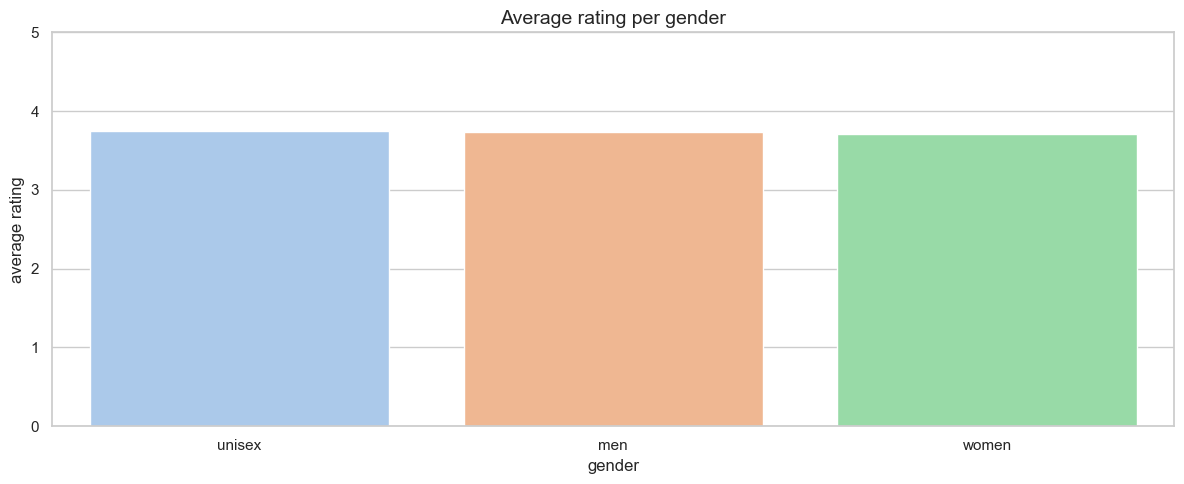

,mean,median,count
gender,,,
unisex,3.753053,3.80,3751
men,3.734842,3.80,1708
women,3.712103,3.75,3865


In [28]:
# Average rating per gender (valid categories only)
if "gender" in df.columns:
    valid = {"women", "men", "unisex"}
    sub = df[df["gender"].isin(valid)].dropna(subset=["rating_num"])
    gr = sub.groupby("gender")["rating_num"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
    plt.figure(figsize=(12, 5))
    sns.barplot(x=gr.index.astype(str), y=gr["mean"], palette="pastel")
    plt.title("Average rating per gender")
    plt.ylabel("average rating")
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.show()
    display(gr)

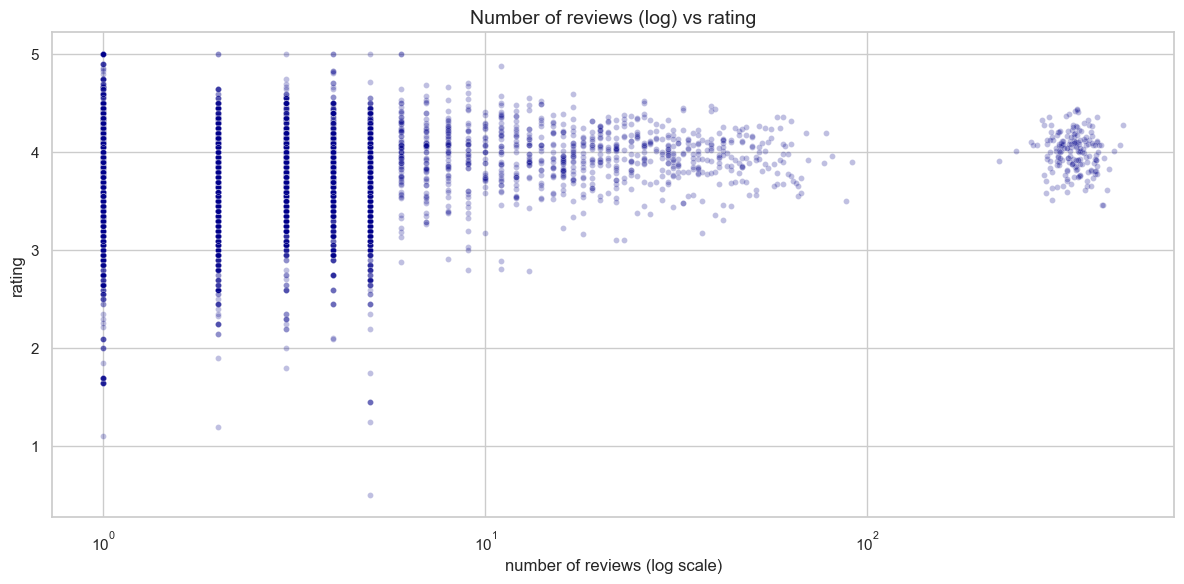

In [29]:
# Number of reviews (n_reviews) vs rating (scatter, log x)
s = df[["n_reviews", "rating_num"]].dropna()
s = s[s["n_reviews"] > 0]
plt.figure(figsize=(12, 6))
sns.scatterplot(data=s, x="n_reviews", y="rating_num", alpha=0.25, s=18, color="darkblue")
plt.xscale("log")
plt.title("Number of reviews (log) vs rating")
plt.xlabel("number of reviews (log scale)")
plt.ylabel("rating")
plt.tight_layout()
plt.show()

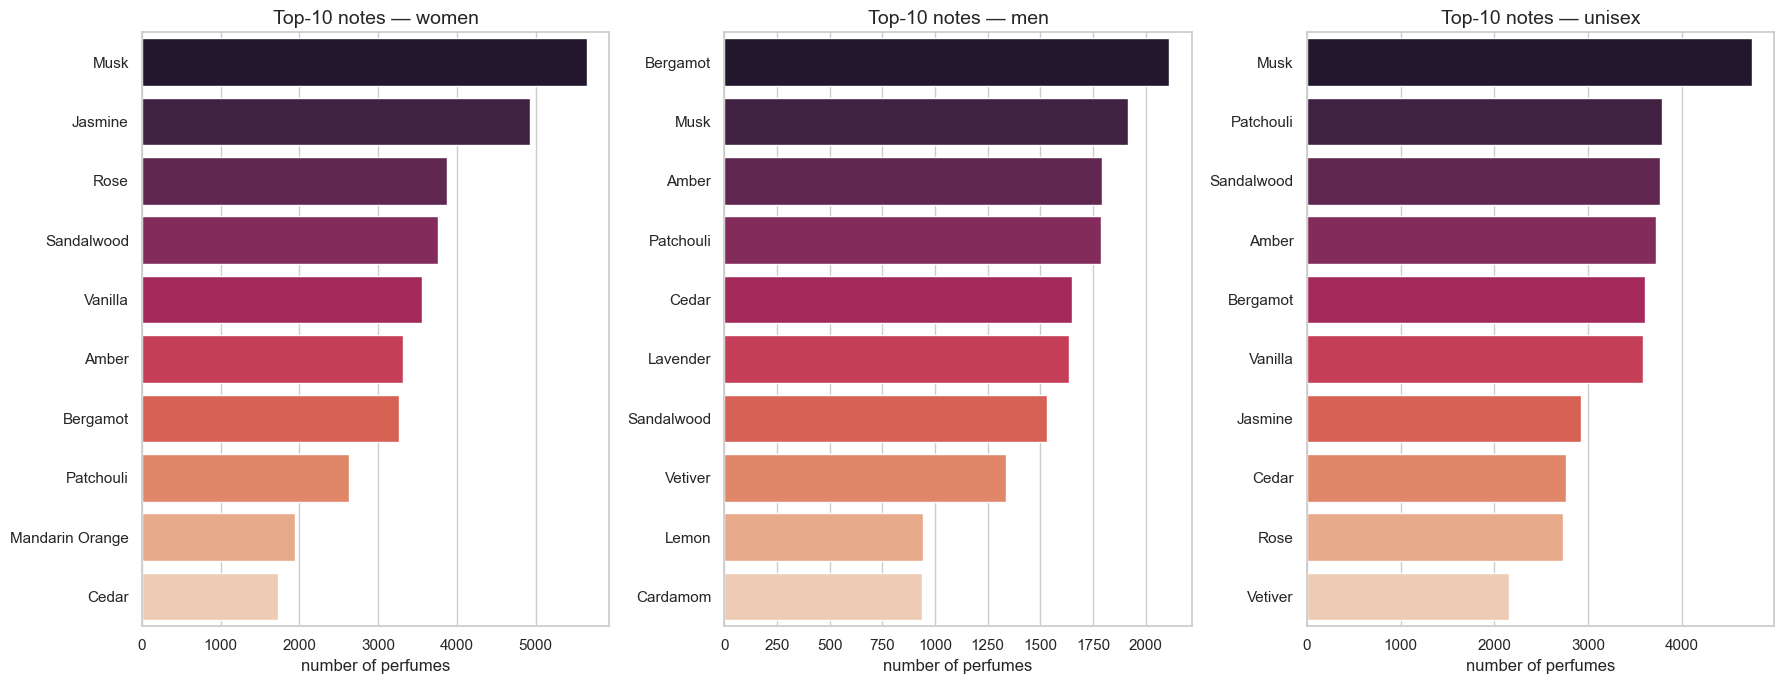

In [30]:
# Most common notes per gender
if "gender" in df.columns:
    rows = []
    for g in ["women", "men", "unisex"]:
        c = Counter()
        for lst in df.loc[df["gender"] == g, "notes_list"]:
            c.update(lst)
        for note, cnt in c.most_common(10):
            rows.append({"gender": g, "note": note, "count": cnt})
    notes_gender = pd.DataFrame(rows)

    g_order = [g for g in ["women", "men", "unisex"] if g in notes_gender["gender"].values]
    fig, axes = plt.subplots(1, len(g_order), figsize=(6 * len(g_order), 7))
    if len(g_order) == 1:
        axes = [axes]
    for ax, g in zip(axes, g_order):
        sub = notes_gender[notes_gender["gender"] == g]
        sns.barplot(data=sub, x="count", y="note", ax=ax, palette="rocket")
        ax.set_title(f"Top-10 notes — {g}")
        ax.set_xlabel("number of perfumes")
        ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

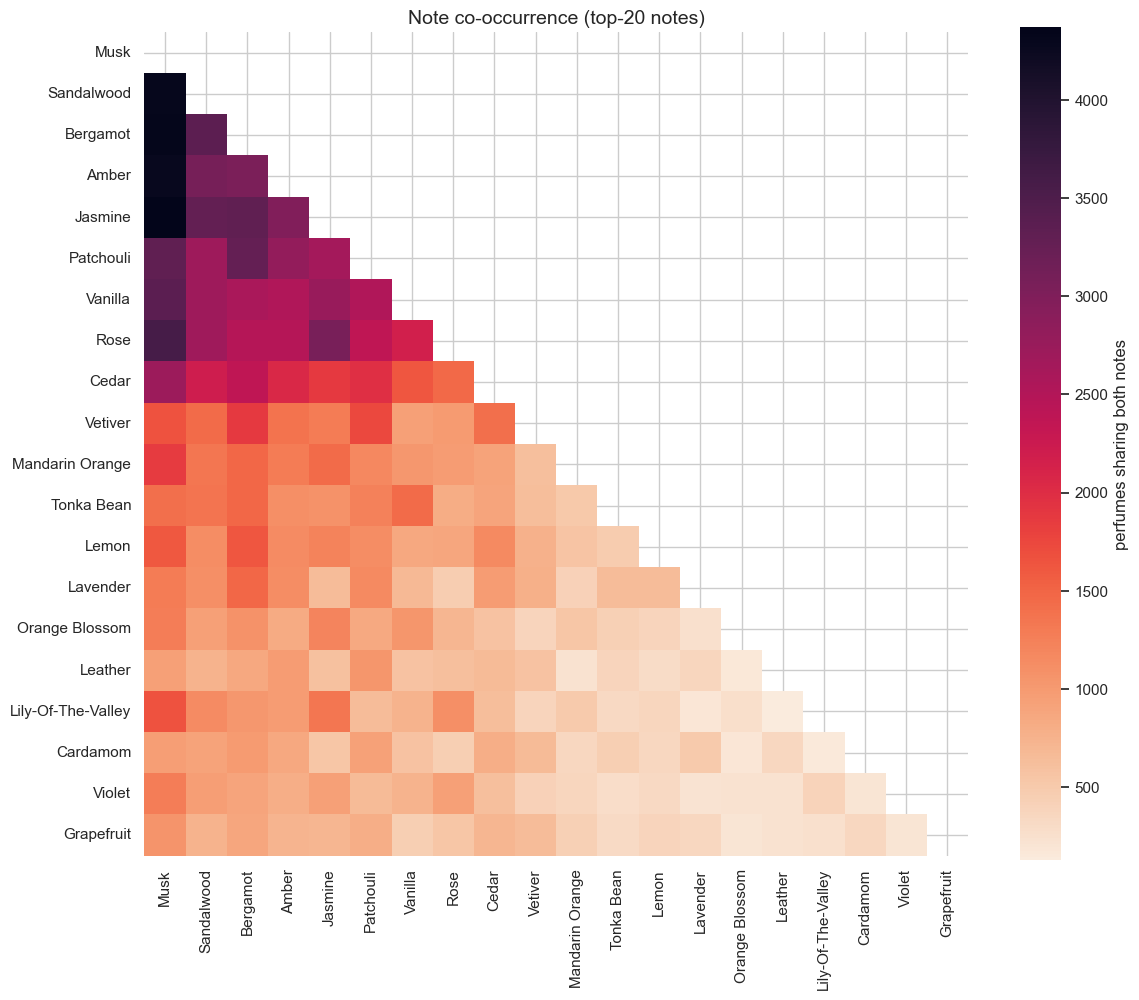

In [31]:
# Note co-occurrence heatmap: which top notes appear together?
# Directly useful for recommendations ("if you like X, you may like Y").
TOP_N = 20
top_note_names = [n for n, _ in note_counter.most_common(TOP_N)]
idx = {n: i for i, n in enumerate(top_note_names)}
co = np.zeros((TOP_N, TOP_N), dtype=int)

for lst in df["notes_list"]:
    present = sorted({idx[n] for n in lst if n in idx})
    for a, b in combinations(present, 2):
        co[a, b] += 1
        co[b, a] += 1

co_df = pd.DataFrame(co, index=top_note_names, columns=top_note_names)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(co, dtype=bool))   # show lower triangle only
sns.heatmap(co_df, mask=mask, cmap="rocket_r", square=True,
            cbar_kws={"label": "perfumes sharing both notes"})
plt.title("Note co-occurrence (top-20 notes)")
plt.tight_layout()
plt.show()

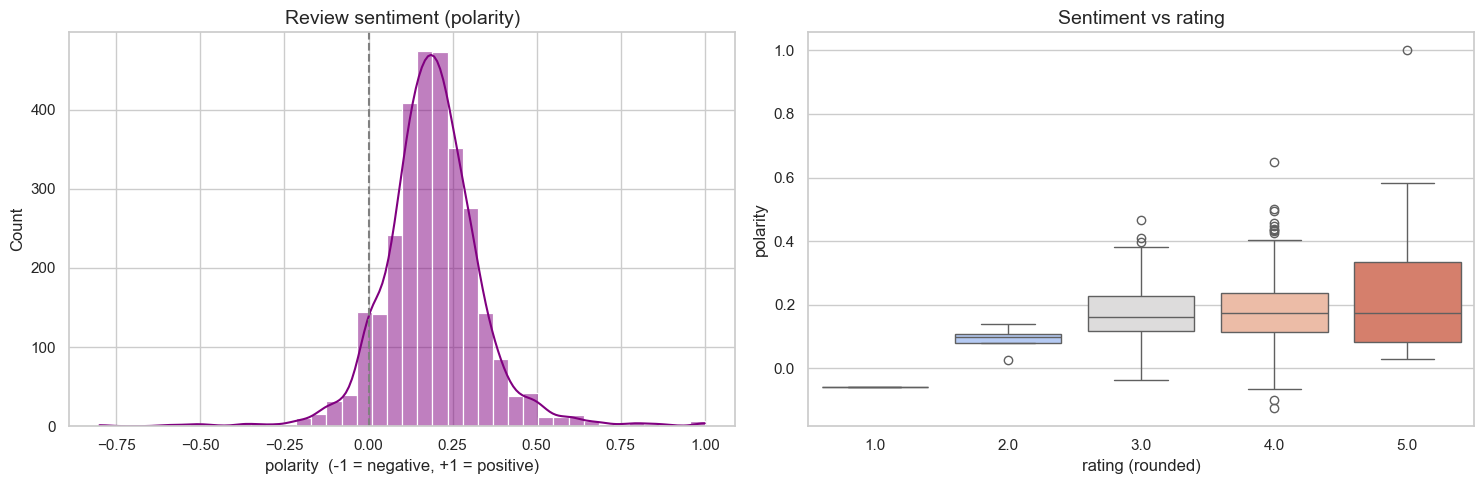

Mean polarity: 0.19 | share positive: 0.92


In [32]:
# Review sentiment (TextBlob) on a sample of non-empty reviews
review_col = "reviews_text" if "reviews_text" in df.columns else "reviews"
rev = df[[review_col, "rating_num"]].copy()
rev["text"] = rev[review_col].fillna("").astype(str)
rev = rev[rev["text"].str.len() >= 20]
rev_sample = rev.sample(min(3000, len(rev)), random_state=42)
rev_sample["polarity"] = rev_sample["text"].apply(lambda t: TextBlob(t).sentiment.polarity)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: sentiment distribution (-1 negative ... +1 positive)
sns.histplot(rev_sample["polarity"], bins=40, kde=True, ax=ax1, color="purple")
ax1.axvline(0, color="grey", linestyle="--")
ax1.set_title("Review sentiment (polarity)")
ax1.set_xlabel("polarity  (-1 = negative, +1 = positive)")

# Right: sentiment vs rating (binned)
both = rev_sample.dropna(subset=["rating_num"]).copy()
if len(both) > 10:
    both["rating_bin"] = both["rating_num"].round()
    sns.boxplot(data=both, x="rating_bin", y="polarity", ax=ax2, palette="coolwarm")
ax2.set_title("Sentiment vs rating")
ax2.set_xlabel("rating (rounded)")
ax2.set_ylabel("polarity")
plt.tight_layout()
plt.show()

print("Mean polarity:", round(rev_sample["polarity"].mean(), 3),
      "| share positive:", round((rev_sample["polarity"] > 0).mean(), 3))

### Findings combination analyses

- **Designer vs rating:** The highest-scoring brands are often niche houses with a loyal audience. The min.-5-perfumes filter stops a single 5-star perfume from topping the list.
- **Gender vs rating:** Average rating barely differs by gender; unisex and women sit slightly above men, but the gap is small.
- **Reviews vs rating:** On a log scale, perfumes with few reviews have noisy ratings, while heavily reviewed perfumes settle around 3.5–4.0.
- **Notes per gender:** Women leans floral/sweet (Rose, Jasmine, Vanilla), men leans woody/spicy (Cedar, Vetiver, Pepper), unisex sits in between with lots of Musk and Sandalwood.
- **Note co-occurrence:** Clear pairs stand out (e.g. Musk + Sandalwood, Bergamot + Vanilla). This is the most directly useful chart for note-based recommendations.
- **Sentiment:** Reviews skew positive overall, and higher ratings line up with higher sentiment a good sign that the review text is consistent with the scores.

## 7. Embedding readiness

The single most important view for a RAG/recommendation engine: how many perfumes actually have the fields we need to build good embeddings and metadata.

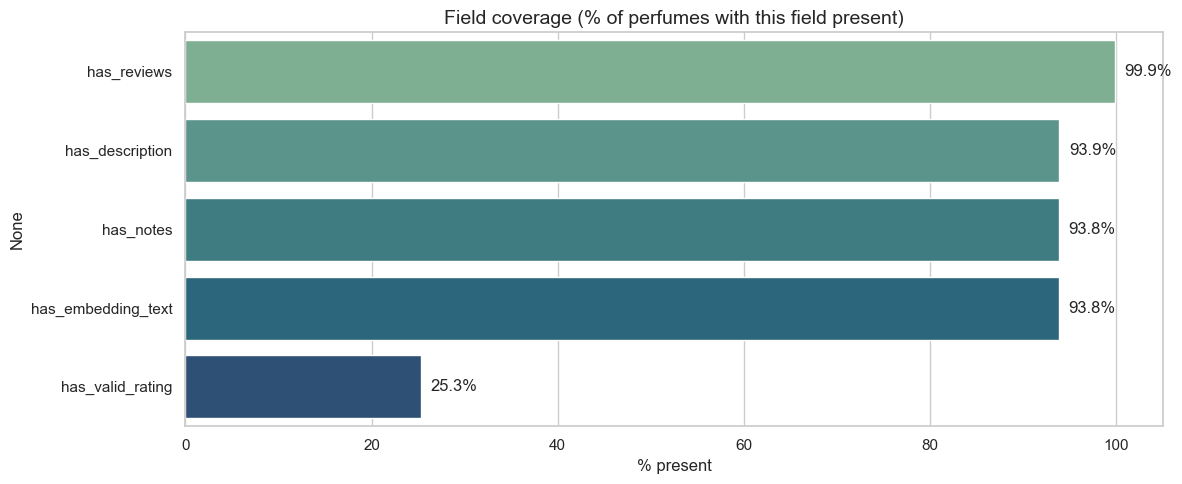

Perfumes with description + notes            : 35184 (93.8%)
Perfumes with description + notes + rating   : 9324 (24.9%)


In [33]:
# Per-row availability of key fields
flags = pd.DataFrame({
    "has_description": df["description"].fillna("").astype(str).str.strip().ne("") if "description" in df else False,
    "has_notes":       df["n_notes"] > 0,
    "has_valid_rating": df["rating_num"].notna(),
    "has_reviews":     df["n_reviews"] > 0,
    "has_embedding_text": df["embedding_text"].fillna("").astype(str).str.strip().ne("") if "embedding_text" in df else False,
})

coverage = (flags.mean() * 100).round(1).sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=coverage.values, y=coverage.index, palette="crest")
for i, v in enumerate(coverage.values):
    plt.text(v + 1, i, f"{v}%", va="center")
plt.title("Field coverage (% of perfumes with this field present)")
plt.xlabel("% present")
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

# Core combo for retrieval: description + notes present
core = flags["has_description"] & flags["has_notes"]
core_rated = core & flags["has_valid_rating"]
print(f"Perfumes with description + notes            : {core.sum()} ({core.mean()*100:.1f}%)")
print(f"Perfumes with description + notes + rating   : {core_rated.sum()} ({core_rated.mean()*100:.1f}%)")

### Findings embedding readiness

- `embedding_text`, `description` and `notes` are present for the large majority of perfumes good news for building embeddings.
- A valid `rating` is the scarcest field (~25%), so rating should be treated as optional metadata, not a hard requirement.
- The usable core for retrieval (description + notes) covers most of the dataset; adding a valid rating shrinks it a lot. Build the vector store on description + notes, and attach rating only where it exists.

## 8. Conclusion

### 8.1 Text columns
- **`title`**  short, has brand + gender; a compact id, but partly polluted by shifted rows.
- **`description`**  rich free text, mostly English, ~6% empty. The most valuable column for semantic embeddings.
- **`notes` / `notes_text`** perfume notes; `notes` is a list-string, `notes_text` is comma text. After parsing, very useful for note-based filtering and recommendations.
- **`reviews` / `reviews_text`**  user reviews (list vs text form). `reviews_text` is ~15% empty and varies a lot in length. Rich but noisy; sentiment is mostly positive.
- **`embedding_text`**  combined field of the other text fields; longest column, meant as direct input for the embedding model (~6% empty).

### 8.2 Numeric columns
- **`rating`**  scale 0–5, peak around 3.5–4.0, but only ~25% of rows have a valid value. Useful as a quality signal **if filtered**.
- **`reviews`**  not a number but review text. The derived **`n_reviews`** is the usable numeric measure; strongly right-skewed.

### 8.3 Data quality problems
1. **Column explosion / shifted rows:** the raw file has far more than 13 columns because multi-line review text leaked during CSV parsing. This also pollutes `rating`, `title`, `gender` and `style` per row.
2. **`rating` mostly unusable without filtering** (~75% empty/polluted, dtype `object`).
3. **`reviews` is text, not a count**  use `n_reviews` for volume.
4. **`style` almost empty** (>90%) and polluted — unusable as-is.
5. **Duplicates** on `url`/`title`.
6. **Mixed languages** in text fields.
7. **Inconsistent note names** (variants, casing, duplicates) need normalising.

### 8.4 Recommendations for the LLM / RAG model
1. **Re-ingest the source:** re-parse the original CSV with correct quoting/escaping of multi-line review text so `rating`/`gender`/`title` stop shifting. This fixes most problems at the root.
2. **Deduplicate on `url`** before generating embeddings.
3. **Clean `embedding_text`**: strip HTML/odd characters, flag or translate non-English text, drop empty rows.
4. **Normalise notes** (lowercase, dedupe, synonym mapping) and store them as separate metadata for filtered retrieval (e.g. "only perfumes with oud"). Use the co-occurrence signal for "similar notes".
5. **Numeric metadata** (`rating`, `n_reviews`) as filter/booster, with a minimum review count for trust and only valid ratings in `[0, 5]`.
6. **Gender and designer as filterable metadata**; limit gender to women/men/unisex.
7. **Ignore `style`** until the source is re-ingested.
8. **Minimum length for review text** (e.g. >= 20 chars) before adding a review to the embedding, to cut noise.

